La libreria **sklearn.cluster** fornisce una suite di algoritmi per il clustering non supervisionato, il cui scopo è raggruppare dati non etichettati in base alla loro somiglianza. Questi metodi sono fondamentali per l'analisi esplorativa dei dati, poiché permettono di scoprire strutture intrinseche, come gruppi o sottogruppi, senza la necessità di informazioni preesistenti sulle categorie. Tra i principali algoritmi troviamo:

-   **K-Means**: Partiziona i dati in un numero predefinito di cluster (K) a forma sferica.
-   **Agglomerative Clustering**: Costruisce una gerarchia di cluster in modo bottom-up.
-   **DBSCAN**: Raggruppa i dati basandosi sulla densità, identificando cluster di forma arbitraria e outlier.

L'algoritmo K-Means mira a partizionare `n` osservazioni in `k` cluster, in cui ogni osservazione appartiene al cluster con il centroide (media) più vicino. Funziona in modo iterativo per minimizzare la varianza all'interno di ciascun cluster (inerzia).

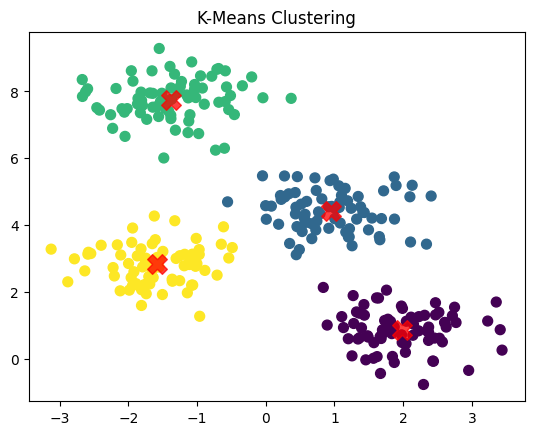

Cluster centers:
 [[ 1.98258281  0.86771314]
 [ 0.94973532  4.41906906]
 [-1.37324398  7.75368871]
 [-1.58438467  2.83081263]]


In [1]:
# Esempio: Applicazione di K-Means
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Genera dati di esempio
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Crea e addestra il modello K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Visualizza i risultati
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('K-Means Clustering')
plt.show()

print("Cluster centers:\n", centers)

L'Agglomerative Clustering è un approccio di clustering gerarchico che costruisce una gerarchia di cluster partendo da singoli punti. Ad ogni passo, unisce le due coppie di cluster più vicine secondo una metrica di linkage (es. `ward`, `complete`, `average`).

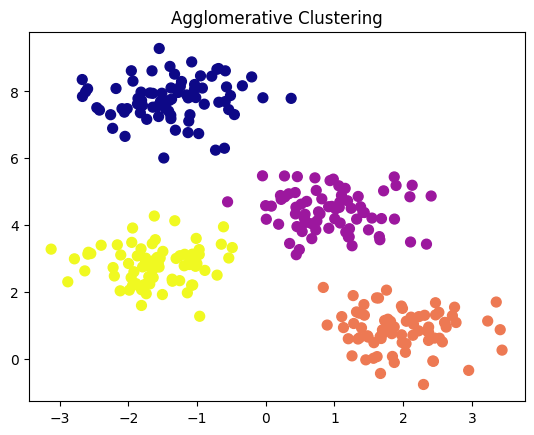

In [2]:
# Esempio: Applicazione dell'Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

# Crea e addestra il modello
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_agg = agg_clustering.fit_predict(X)

# Visualizza i risultati
plt.scatter(X[:, 0], X[:, 1], c=y_agg, s=50, cmap='plasma')
plt.title('Agglomerative Clustering')
plt.show()

DBSCAN raggruppa i punti che sono densamente concentrati, contrassegnando come outlier i punti che si trovano in regioni a bassa densità. È particolarmente efficace per identificare cluster di forma non sferica e per gestire il rumore nei dati. I parametri chiave sono `eps` (la distanza massima tra due campioni per essere considerati vicini) e `min_samples` (il numero minimo di campioni in un intorno per formare un cluster).


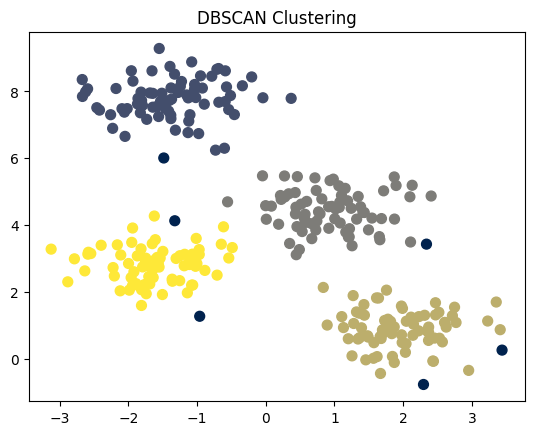

Numero di cluster stimati: 4


In [3]:
# Esempio: Applicazione di DBSCAN
from sklearn.cluster import DBSCAN

# Crea e addestra il modello DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# Visualizza i risultati
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, s=50, cmap='cividis')
plt.title('DBSCAN Clustering')
plt.show()

# Stampa il numero di cluster trovati (escludendo il rumore, etichettato come -1)
n_clusters_ = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
print(f'Numero di cluster stimati: {n_clusters_}')